In [1]:
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
import matplotlib.pyplot as plt

os.chdir('..')
print("Current folder:", os.getcwd())

Current folder: c:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map


NO2: shape=(57, 68), resolution=(0.008983152841195215, 0.008983152841195215)
Elevation: shape=(1858, 2228), resolution=(0.00026949458523585647, 0.00026949458523585647)
Land Use: shape=(113, 135), resolution=(0.004491576420597608, 0.004491576420597608)
Population: shape=(558, 669), resolution=(0.0008983152841195215, 0.0008983152841195215)


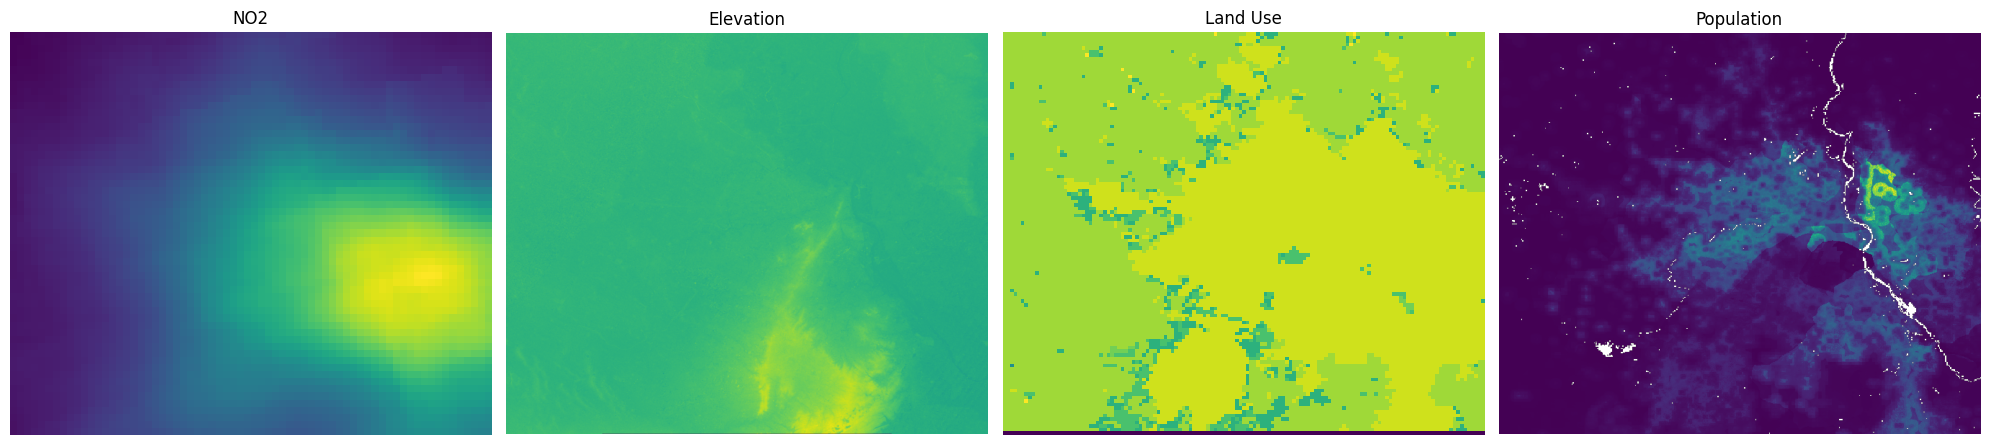

In [2]:
# Load all datasets
datasets = {
    'NO2': 'data/raw/delhi_no2_2023.tif',
    'Elevation': 'data/raw/delhi_elevation.tif',
    'Land Use': 'data/raw/delhi_landuse.tif',
    'Population': 'data/raw/delhi_population.tif'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, path) in zip(axes, datasets.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        res = src.res                    # pixel resolution
        shape = src.read(1).shape        # rows x columns
        print(f"{name}: shape={shape}, resolution={res}")
    
    data = np.where(data < 0, np.nan, data)
    ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/all_datasets_raw.png', dpi=300)
plt.show()

In [3]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform

# Land use will be our reference grid
reference_path = 'data/raw/delhi_landuse.tif'

# All datasets we need to align
datasets_to_align = {
    'no2': 'data/raw/delhi_no2_2023.tif',
    'elevation': 'data/raw/delhi_elevation.tif',
    'population': 'data/raw/delhi_population.tif',
    'landuse': 'data/raw/delhi_landuse.tif'
}

# Read reference grid properties
with rasterio.open(reference_path) as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height
    ref_profile = ref.profile
    print(f"Reference grid: {ref_height} x {ref_width}")
    print(f"CRS: {ref_crs}")

print("✅ Reference grid loaded!")

Reference grid: 113 x 135
CRS: EPSG:4326
✅ Reference grid loaded!


In [4]:
aligned_data = {}

for name, path in datasets_to_align.items():
    with rasterio.open(path) as src:
        # Create empty array matching reference grid size
        aligned = np.zeros(
            (ref_height, ref_width),
            dtype=np.float32
        )
        
        # Reproject this dataset onto reference grid
        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear  
            # bilinear = smooth interpolation
            # like stretching/shrinking a photo smoothly
        )
    
    # Replace invalid values with NaN
    aligned = np.where(aligned <= 0, np.nan, aligned)
    aligned_data[name] = aligned
    
    print(f"✅ {name}: aligned to shape {aligned.shape}")

print("\nAll datasets aligned!")

✅ no2: aligned to shape (113, 135)
✅ elevation: aligned to shape (113, 135)
✅ population: aligned to shape (113, 135)
✅ landuse: aligned to shape (113, 135)

All datasets aligned!


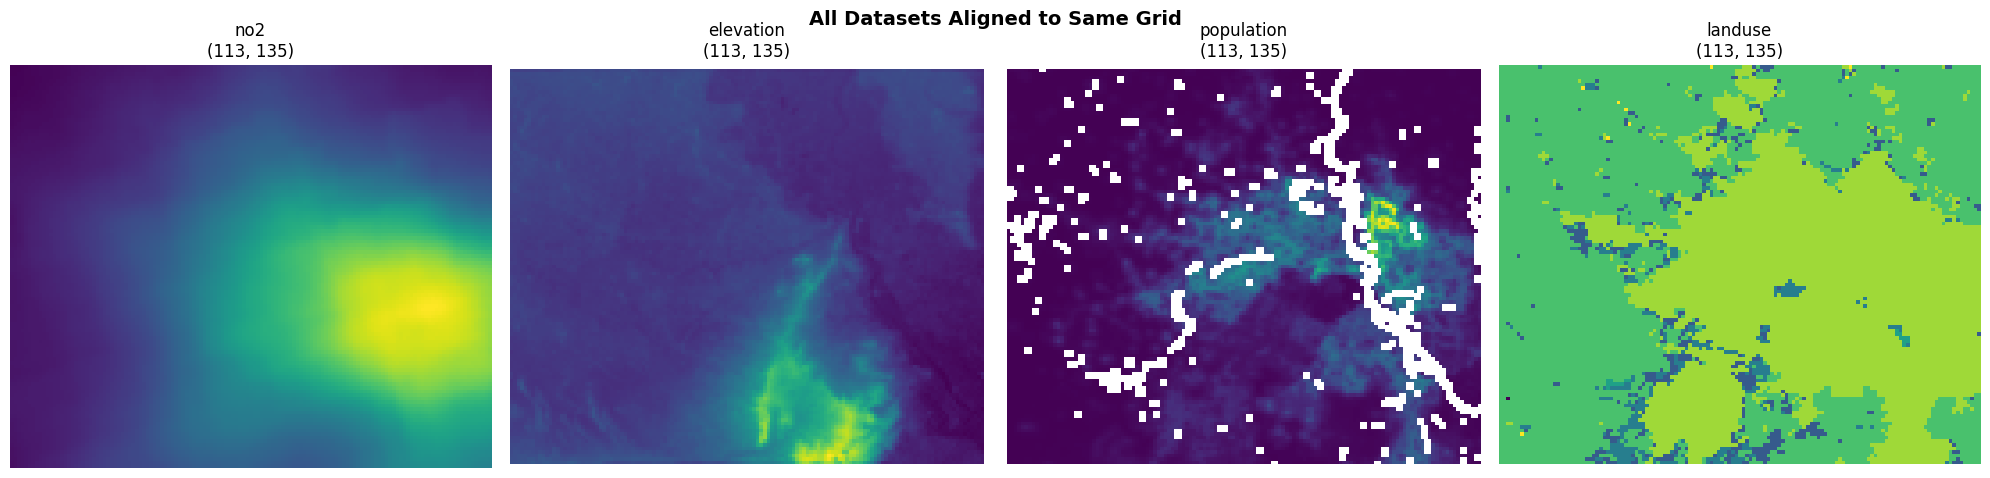

✅ All 4 maps now have identical shapes!


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, data) in zip(axes, aligned_data.items()):
    ax.imshow(data, cmap='viridis')
    ax.set_title(f'{name}\n{data.shape}')
    ax.axis('off')

plt.suptitle('All Datasets Aligned to Same Grid', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/all_datasets_aligned.png', dpi=300)
plt.show()

print("✅ All 4 maps now have identical shapes!")

In [10]:
# Handle Missing Values
from scipy.ndimage import generic_filter

def fill_missing(data):
    filled = data.copy()
    mask = np.isnan(filled)
    
    if mask.sum() == 0:
        print("No missing values found!")
        return filled
    
    print(f"Missing pixels before: {mask.sum()}")
    
    # Replace each missing pixel with the
    # average of its neighbours
    def nanmean_filter(values):
        valid = values[~np.isnan(values)]
        return np.mean(valid) if len(valid) > 0 else np.nan
    
    filled = generic_filter(
        filled,
        nanmean_filter,
        size=5,        # look at 5x5 neighbourhood
        mode='nearest'
    )
    
    print(f"Missing pixels after: {np.isnan(filled).sum()}")
    return filled

# Apply to all datasets
aligned_filled = {}
for name, data in aligned_data.items():
    print(f"\nProcessing {name}...")
    aligned_filled[name] = fill_missing(data)

print("\n✅ Missing values handled!")


Processing no2...
No missing values found!

Processing elevation...
Missing pixels before: 492
Missing pixels after: 0

Processing population...
Missing pixels before: 2079
Missing pixels after: 11

Processing landuse...
Missing pixels before: 135
Missing pixels after: 0

✅ Missing values handled!


In [9]:
# Normalize All Datasets 
from sklearn.preprocessing import MinMaxScaler

def normalize(data):
    # Remember original shape
    original_shape = data.shape
    
    # Flatten to 1D
    flat = data.flatten()
    
    # Find valid (non-NaN) positions
    valid_mask = ~np.isnan(flat)
    
    # Extract only valid values
    valid_values = flat[valid_mask].reshape(-1, 1)
    
    # Scale valid values to 0-1 range
    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(valid_values).flatten()
    
    # Put scaled values back into flat array
    flat_normalized = flat.copy()
    flat_normalized[valid_mask] = scaled_values
    
    # Reshape back to 2D
    normalized = flat_normalized.reshape(original_shape)
    
    print(f"  Min: {np.nanmin(normalized):.3f}, "
          f"Max: {np.nanmax(normalized):.3f}")
    return normalized, scaler

# Apply to all datasets
normalized_data = {}
scalers = {}

for name, data in aligned_filled.items():
    print(f"\nNormalizing {name}...")
    normalized_data[name], scalers[name] = normalize(data)

print("\n✅ All datasets normalized to 0-1 range!")


Normalizing no2...
  Min: 0.000, Max: 1.000

Normalizing elevation...
  Min: 0.000, Max: 1.000

Normalizing population...
  Min: 0.000, Max: 1.000

Normalizing landuse...
  Min: 0.000, Max: 1.000

✅ All datasets normalized to 0-1 range!


In [11]:
# Combine Into ML Dataset
import pandas as pd

# Flatten each dataset into a 1D list of pixels
df = pd.DataFrame({
    'no2':        normalized_data['no2'].flatten(),
    'elevation':  normalized_data['elevation'].flatten(),
    'population': normalized_data['population'].flatten(),
    'landuse':    normalized_data['landuse'].flatten()
})

# Remove rows where ANY value is missing
df_clean = df.dropna()

print(f"Total pixels: {len(df)}")
print(f"Clean pixels: {len(df_clean)}")
print(f"Removed pixels: {len(df) - len(df_clean)}")
print(f"\nFirst 5 rows:")
print(df_clean.head())

# Save to processed folder
df_clean.to_csv('data/processed/ml_dataset.csv', index=False)
print("\n✅ ML dataset saved to data/processed/ml_dataset.csv!")

Total pixels: 15255
Clean pixels: 15244
Removed pixels: 11

First 5 rows:
        no2  elevation  population   landuse
0  0.000000   0.218195    0.008241  0.715909
1  0.000957   0.217592    0.010818  0.715909
2  0.002872   0.217569    0.012778  0.715909
3  0.006267   0.217219    0.014113  0.715909
4  0.011143   0.216328    0.016637  0.715909

✅ ML dataset saved to data/processed/ml_dataset.csv!
